In [ ]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field, ConfigDict, field_validator
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import os
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import SystemMessage, HumanMessage

import psycopg
from psycopg.rows import dict_row
from langgraph.checkpoint.postgres import PostgresSaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq

from enum import Enum

load_dotenv()

True

In [540]:

def get_database_url():
    database_url = os.getenv("DATABASE_URL")

    if not database_url:
        raise ValueError(
            "DATABASE_URL is missing. Please add your Render PostgreSQL External Database URL to .env"
        )

    if "sslmode=" not in database_url:
        separator = "&" if "?" in database_url else "?"
        database_url = f"{database_url}{separator}sslmode=require"

    return database_url

In [ ]:
GROK_API_KEY = os.getenv("GROK_API_KEY")
if not GROK_API_KEY:
    raise ValueError("GROK_API_KEY is missing. Please add it to your .env file.")

In [542]:
class Task(BaseModel):
    

    task_id: str = Field(
        description="Unique identifier for the research task."
    )

    title: str 

    objective: str = Field(
        description="Specific research objective that this task must accomplish."
    )

    search_query: str = Field(
        description="Search query or queries that the worker should use to find relevant resources."
    )

    expected_output: str



In [543]:
class Plan(BaseModel):
    
    topic: str = Field(
        description="The technical topic provided by the user."
    )

    objective: str = Field(
        description="Overall objective of the resource planning request."
    )

    task_budget: int = Field(
        description="Maximum number of meaningful research tasks allowed for this plan. Maximum number of task allowed is 8"
    )

    tasks: list[Task] = Field(
        description="Research tasks required to sufficiently cover the topic."
    )


In [544]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]  # reducer concatenates worker outputs
    final: str

In [545]:
llm = ChatNVIDIA(
    model="meta/muse-glimmer-30b",
    api_key=NVIDIA_API_KEY,
    timeout=180
)

/Users/saravanakarthikeyan/AI_Project_Capstone/Agentic_AI/Agent_one/Tech-ResourcePalnner-Agent-AI/.venv/lib/python3.13/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found meta/muse-glimmer-30b in available_models, but type is unknown and inference may fail.
  warnings.warn(


In [546]:
def orchestrator(state: State) -> dict:
    planner = llm.with_structured_output(Plan)

    plan = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical researcher and learning-path designer. Your job is to "
                    "produce a highly actionable research plan for someone learning a technical topic.\n\n"
                    "Hard requirements:\n"
                    "- Create 4-8 tasks (never exceed task_budget), each covering one independent, "
                    "researchable sub-topic.\n"
                    "- Each task must include:\n"
                    "  1) objective (1-2 sentences: exactly what this task must find out)\n"
                    "  2) search_query (concise, specific, as you'd type into a search engine)\n"
                    "  3) expected_output (1-2 sentences: exactly what the learner should produce or learn from this task)\n"
                    "- Assume the learner is a developer; use correct terminology in objectives and "
                    "search_query.\n"
                    "- Prefer a natural learning structure: fundamentals → core mechanics → intermediate "
                    "patterns → advanced/production concerns → real-world projects.\n"
                    "- Tasks must be concrete and specific, not vague (e.g. 'Find resources explaining "
                    "Core Concepts', not 'not just the outline').\n"
                    "- Explicitly include at least ONE task that targets something practical, such as:\n"
                    "  * a hands-on tutorial or minimal working example\n"
                    "  * production/deployment considerations\n"
                    "  * common pitfalls or debugging/observability resources\n"
                    "  * a real-world or open-source project using the topic\n"
                    "- expected_output must be specific and testable (e.g. 'A ranked list of 2-3 official "
                    "docs and 1-2 tutorials on X, each with a one-line summary and a recommended reading "
                    "order'), never vague like 'Information about X'.\n\n"
                    "Ordering guidance:\n"
                    "- Order tasks the way a learner would naturally encounter them: fundamentals first, "
                    "advanced/production topics last. This ordering is for readability only — tasks must "
                    "remain independently researchable with no dependency on another task's output.\n"
                    "- Do not let tasks overlap — each should own a distinct slice of the topic, "
                    "consistent with the plan's scope.\n\n"
                    "Output must strictly match the Plan schema.\n\n"
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    return {"plan": plan}

In [547]:
def fanout(state: State):
    return [
        Send(
            "worker",
            {"task": task, "topic": state["topic"], "plan": state["plan"]},
        )
        for task in state["plan"].tasks
    ]

In [548]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    result = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical researcher and developer advocate. Research "
                    "ONE task from a technical resource plan and write up the findings as a "
                    "single section of a Markdown research report.\n\n"
                    "Hard constraints:\n"
                    "- Follow the provided Task objective exactly, and produce what "
                    "Expected output describes — no more, no less.\n"
                    "- Output ONLY the section content in Markdown (no blog title H1, no "
                    "extra commentary, no restating of the task instructions).\n\n"
                    "Research quality bar:\n"
                    "- Be precise and evaluative, not just a list of links — a reader should "
                    "know why each resource is worth their time.\n"
                    "- Prefer concrete specifics over vague praise: what exactly the resource "
                    "covers, what level it's pitched at, and what a learner will walk away "
                    "with.\n"
                    "- For each resource, briefly note credibility (official docs / "
                    "established author vs. general blog) and recency, flagging anything "
                    "that looks outdated for a fast-moving topic.\n"
                    "- When relevant, include at least one of:\n"
                    "  * a recommended reading/viewing order across the resources\n"
                    "  * a short note on what to skip or skim vs. read in full\n"
                    "  * a one-line summary of what each resource actually teaches\n"
                    "- Call out any gaps (resource types requested but not found) and what "
                    "that means for the learner.\n\n"
                    "Markdown style:\n"
                    "- Start with a '## <Task title>' heading.\n"
                    "- Use short paragraphs and bullet lists per resource; use a sub-bullet "
                    "or short note under each resource, not a wall of text.\n"
                    "- Avoid fluff. Avoid marketing language.\n"
                    "- Keep resource notes focused on this task's objective only.\n"
                )
            ),
            HumanMessage(
                content=(
                    f"Plan topic: {plan.topic}\n"
                    f"Plan objective: {plan.objective}\n"
                    f"Task ID: {task.task_id}\n"
                    f"Task title: {task.title}\n"
                    f"Task objective: {task.objective}\n"
                    f"Search query: {task.search_query}\n"
                    f"Expected output: {task.expected_output}\n"                    
                )
            ),
        ]
        
    )

    return {"sections": [result.content.strip()]}

In [549]:
from pathlib import Path
def reducer(state: State) -> dict:
    plan = state["plan"]

    body = "\n\n---\n\n".join(state["sections"]).strip()

    final_md = (
        f"# {plan.topic}\n\n"
        f"**Objective:** {plan.objective}\n\n"
        f"---\n\n"
        f"{body}\n"
    )

    filename = "".join(
        c if c.isalnum() or c in (" ", "_", "-") else "" for c in plan.topic
    )
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [550]:

# -----------------------------
# 5) Graph
# -----------------------------
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

In [551]:

# =========================
# PostgreSQL Checkpointer
# =========================
DATABASE_URL = get_database_url()

_conn = psycopg.connect(
    DATABASE_URL,
    autocommit=True,
    row_factory=dict_row
)

checkpointer = PostgresSaver(_conn)
checkpointer.setup()

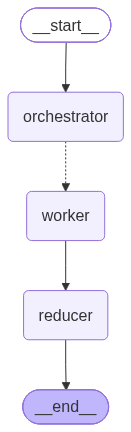

In [552]:
app = g.compile(checkpointer=checkpointer)

app

In [553]:
import uuid
config = {
        "configurable": {
            "thread_id": str(uuid.uuid4())
        }
    }

In [554]:
out = app.invoke({"topic": "I want resources to learn LangGraph.", "sections": []}, config=config)

/Users/saravanakarthikeyan/AI_Project_Capstone/Agentic_AI/Agent_one/Tech-ResourcePalnner-Agent-AI/.venv/lib/python3.13/site-packages/langchain_nvidia_ai_endpoints/chat_models.py:1283: UserWarning: Model 'meta/muse-glimmer-30b' is not known to support structured output. Your output may fail at inference time.
  warnings.warn(


Exception: [400] Failed to deserialize the JSON body into the target type: unknown field `guided_json`, expected one of `greed_sampling`, `use_raw_prompt`, `annotations`, `backend_instance_id`, `token_data`, `max_thinking_tokens`, `cache_salt`, `extra_fields`, `metadata_upload`, `prefill_worker_id`, `decode_worker_id`, `dp_rank`, `prefill_dp_rank`, `agent_hints`, `request_timestamp_ms`, `routing_constraints`, `router` at line 1 column 2125
{'message': 'Failed to deserialize the JSON body into the target type: unknown field `guided_json`, expected one of `greed_sampling`, `use_raw_prompt`, `annotations`, `backend_instance_id`, `token_data`, `max_thinking_tokens`, `cache_salt`, `extra_fields`, `metadata_upload`, `prefill_worker_id`, `decode_worker_id`, `dp_rank`, `prefill_dp_rank`, `agent_hints`, `request_timestamp_ms`, `routing_constraints`, `router` at line 1 column 2125', 'type': 'Bad Request', 'code': 400, 'status': 400}